# Visualización del dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/iquitos_indice_calor.csv", parse_dates=["fecha_hora"])
df.head()

,fecha_hora,temperatura,punto_rocio,anio,mes,hora,humedad_relativa,indice_calor
0,2000-01-01 00:00:00-05:00,25.0,24.0,2000,1,0,94.191012,26.014988
1,2000-01-01 01:00:00-05:00,25.0,23.6,2000,1,1,91.951467,25.956511
2,2000-01-01 02:00:00-05:00,25.0,24.0,2000,1,2,94.191012,26.014988
3,2000-01-01 03:00:00-05:00,24.0,23.0,2000,1,3,94.148645,24.913881
4,2000-01-01 04:00:00-05:00,23.0,23.0,2000,1,4,100.000000,23.966667


## El dia tipico de Iquitos

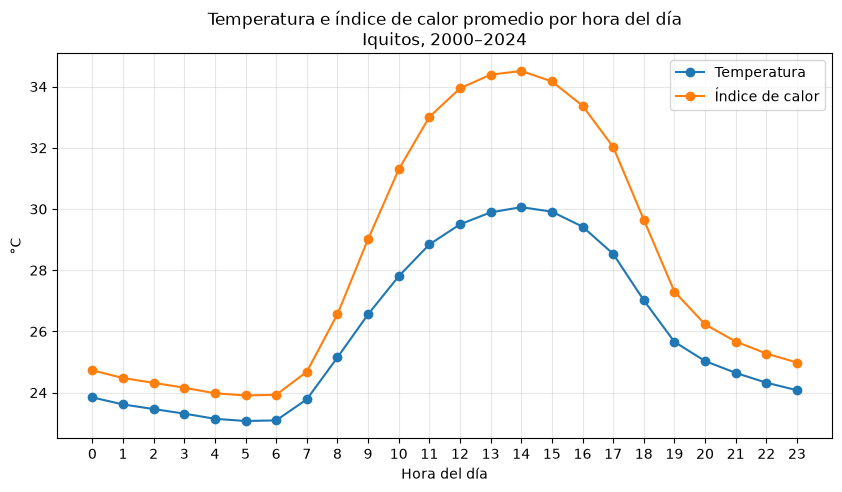

In [2]:
import matplotlib.pyplot as plt

# Promedio de cada variable para cada hora del día
perfil = df.groupby("hora")[["temperatura", "indice_calor"]].mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(perfil.index, perfil["temperatura"], marker="o", label="Temperatura")
ax.plot(perfil.index, perfil["indice_calor"], marker="o", label="Índice de calor")

ax.set_title("Temperatura e índice de calor promedio por hora del día\nIquitos, 2000–2024")
ax.set_xlabel("Hora del día")
ax.set_ylabel("°C")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(alpha=0.3)

plt.savefig("../images/perfil_horario.png", dpi=150, bbox_inches="tight")
plt.show()

- El calor es mas intenso a las 14:00 horas del dia
- La mayor diferencia entre la Temperatura y el Índice de calor es a las 14:00, con una diferencia de 4 C°
- No hay una hora donde las dos linea se toquen, cuando es muy seco deberia estar juntas

In [6]:
diferencia = perfil["indice_calor"] - perfil["temperatura"]
print(diferencia.idxmax(), "h →", round(diferencia.max(), 2), "°C")

13 h → 4.5 °C


In [7]:
df.groupby("hora")["humedad_relativa"].mean()

hora
0     93.148227
1     93.456054
2     93.928090
3     94.176653
4     94.318514
5     94.615016
6     94.637450
7     93.253787
8     88.653558
9     83.116380
10    78.244239
11    74.215827
12    71.426132
13    69.510645
14    68.601201
15    68.807380
16    70.508819
17    74.110237
18    80.657908
19    86.416833
20    89.210471
21    90.710342
22    91.658965
23    92.544995
Name: humedad_relativa, dtype: float64

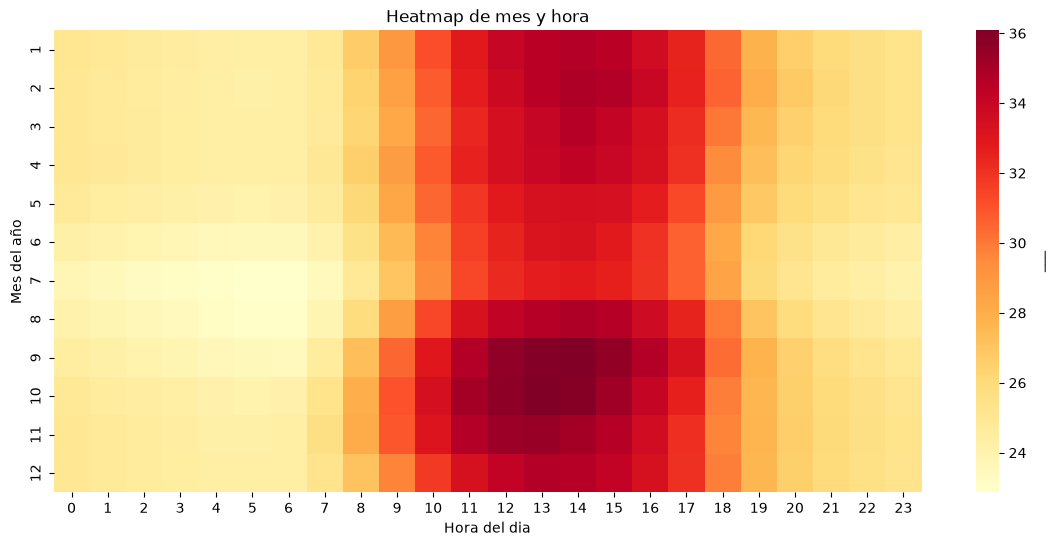

In [3]:
import seaborn as sns

tabla = df.pivot_table(index="mes", columns="hora", values="indice_calor", aggfunc="mean")
tabla

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(tabla, cmap="YlOrRd", ax=ax, cbar_kws={"label": "___"})

ax.set_title("Heatmap de mes y hora")
ax.set_xlabel("Hora del dia")
ax.set_ylabel("Mes del año")

plt.savefig("../images/heatmap_indice_calor.png", dpi=150, bbox_inches="tight")
plt.show()

Gracias al gráfico podemos notar que en las horas de 12:00 a 15:00 de setiembre a octubre presenta mayor temperatura.

In [8]:
df["precaucion_extrema"] = df["indice_calor"] >= 32

# Porcentaje de horas de cada mes en precaución extrema
pct_mes = df.groupby("mes")["precaucion_extrema"].mean() * 100

# Convertido a horas por día
horas_dia = (pct_mes * 24 / 100).round(1)
horas_dia

mes
1     5.8
2     5.9
3     5.5
4     5.4
5     4.8
6     4.4
7     4.5
8     6.1
9     6.9
10    6.8
11    6.4
12    5.9
Name: precaucion_extrema, dtype: float64

In [9]:
df.head()

,fecha_hora,temperatura,punto_rocio,anio,mes,hora,humedad_relativa,indice_calor,precaucion_extrema
0,2000-01-01 00:00:00-05:00,25.0,24.0,2000,1,0,94.191012,26.014988,False
1,2000-01-01 01:00:00-05:00,25.0,23.6,2000,1,1,91.951467,25.956511,False
2,2000-01-01 02:00:00-05:00,25.0,24.0,2000,1,2,94.191012,26.014988,False
3,2000-01-01 03:00:00-05:00,24.0,23.0,2000,1,3,94.148645,24.913881,False
4,2000-01-01 04:00:00-05:00,23.0,23.0,2000,1,4,100.000000,23.966667,False


In [10]:
df["precaucion_extrema"] = df["indice_calor"] >= 32
pct_mes = df.groupby("mes")["precaucion_extrema"].mean() * 100
horas_dia = (pct_mes * 24 / 100).round(1)
horas_dia

mes
1     5.8
2     5.9
3     5.5
4     5.4
5     4.8
6     4.4
7     4.5
8     6.1
9     6.9
10    6.8
11    6.4
12    5.9
Name: precaucion_extrema, dtype: float64

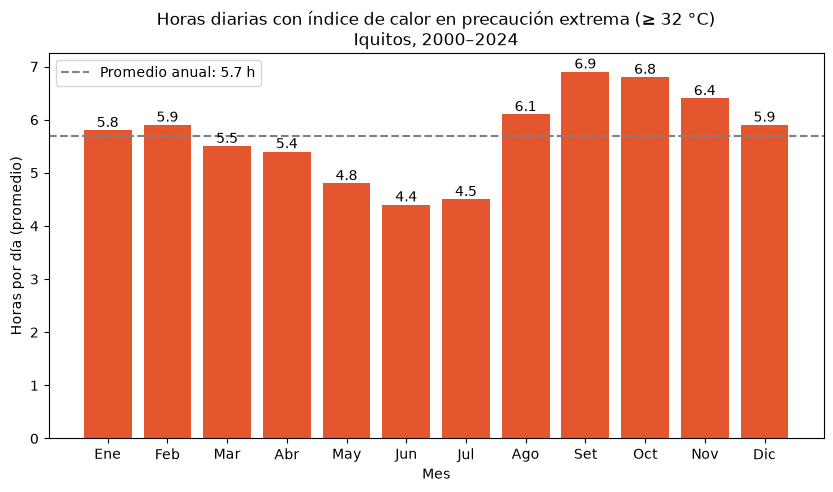

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

# Barras con su valor encima
barras = ax.bar(horas_dia.index, horas_dia.values, color="#E4572E")
ax.bar_label(barras, fmt="%.1f")

# Título y ejes
ax.set_title("Horas diarias con índice de calor en precaución extrema (≥ 32 °C)\nIquitos, 2000–2024")
ax.set_xlabel("Mes")
ax.set_ylabel("Horas por día (promedio)")

# Nombres de los meses
meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Set", "Oct", "Nov", "Dic"]
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)

# Línea del promedio anual
promedio = horas_dia.mean()
ax.axhline(promedio, color="gray", linestyle="--", label=f"Promedio anual: {promedio:.1f} h")
ax.legend()

plt.savefig("../images/horas_calor_extremo.png", dpi=150, bbox_inches="tight")
plt.show()